In [ ]:
#구글드라이브에 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#필요한 라이브러리 및 모듈 불러오기
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

##프로젝트 : Telco Customer Churn Analysis

본 프로젝의 목표는 통신사 고객 데이터를 활용해 **고객 이탈(churn)에 영향을 미치는 요인**을 파악하고   
**이탈 가능 고객을 예측하는 모델을 구축**하여   
실제 비즈니스에 활용 가능한 **고객 유지 전략**을 제안하는 것임.

###**조: C4**
###**조원 : 박의진 / 윤준성**
### **분석 흐름**

1. 데이터 구조 확인 및 전처리
2. EDA와 가설 설정
3. 통계 검정과 예측 모델링
4. 인사이트 요약 및 전략 제언

---
## 1. 데이터 로드 및 구조 확인

- 데이터의 크기와 컬럼 구성 파악
- 타겟 변수(Churn)의 분포 확인
- 전처리가 필요한 변수 식별

In [ ]:
#1-1.데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
#1-2.데이터 기본 구조와 기초 통계량 확인
print(df.shape)
print(df.info())
print(df.describe())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

### 1-1. 데이터 구조 및 통계치 결과
- **총 7,043명의 고객, 21개 변수** 데이터
- 일단 결측은 없어 보임
- 변수 중 수치형 3개(`SeniorCitizen`, `tenure`, `MonthlyCharges`), 범주형 18개
- 타겟 변수인 `Churn(이탈여부)`은 현재 **문자형(object)**으로 저장되어 있어,
  이후 모델 학습을 위해 숫자형 변환이 필요
- `TotalCharges` 역시 수치적 의미를 가지지만 object 타입이므로 전처리가 필요
- `SeniorCitizen`은 0/1 이진 변수로, **약 16%의 고객이 고령자**임
- `tenure(가입기간)`의 평균은 약 **32개월**, 최대 72개월로,
  신규 고객부터 장기 고객까지 폭넓게 분포되어 있다.
- `MonthlyCharges(월요금)`는 평균 약 **65달러**, 최대 약 119달러로,
  고객 간 요금 부담의 차이가 존재함을 알 수 있다.

###다음 단계
-> 	Churn과 TotalCharges가 object 타입이라
이후 분석과 모델링을 위해 변환 진행하고, 결측치는 없었으므로 기본적인 중복 여부와 타입 변환 시 생길 수 있는 데이터 누수나 오류 가능성을 가볍게 검토하여 데이터 품질을 체크한다.

In [ ]:
#중복데이타 확인
df.duplicated().sum()
df['customerID'].duplicated().sum()


np.int64(0)

In [ ]:
#아이디 제외한 나머지 컬럼 기준 중복 확인 : 이미 등장했던 행과 동일한 완전히 동링한 행이 몇개 있나? (동일한 행만 카운트 -22쌍)
df.drop(columns=['customerID']).duplicated().sum()

np.int64(22)

In [ ]:
#중복 후보 행 추출
dup_rows = df[df.drop(columns=['customerID']).duplicated(keep=False)]
dup_rows.shape  #중복에 해당되는 행 추출 시 총 42개, 컬럼수 21개

(42, 21)

In [ ]:
#중복된 행들 상세 확인 (컬럼별 서로 다른 값 개수 확인)
dup_rows.sort_values(by='customerID').head(10)
dup_rows.drop(columns=['customerID']).nunique()  # 중복 후보로 뽑힌 행들 중에서 아이디 제외하고 각 컬럼마다 서로 다른 값이 몇개나 있는지 계산


,0
gender,2
SeniorCitizen,2
Partner,1
Dependents,1
tenure,1
PhoneService,1
MultipleLines,1
InternetService,3
OnlineSecurity,2
OnlineBackup,2


### 1-2. 데이터  품질 체크 결과
customerID를 제외한 기준으로 중복 후보 데이터를 분석한 결과,  
일부 변수는 동일하였으나 요금, 서비스 구성, 결제 방식 및 이탈 여부 등  
여러 핵심 변수에서 다양한 값이 존재함을 확인하였다.  
이는 동일 고객의 중복 기록이 아니라,  
유사한 가입 형태를 가진 서로 다른 고객들로 판단하여  
중복 제거 없이 분석을 진행하였다.  
-> **(유사 상품 조합을 지닌 서로 다른 고객이라 판단)**

In [ ]:
# 통계 및 모델링을 위해 문자형을 숫자로 변경
# 타겟 변수 Churn을 0(유지)과 1(이탈)로 변환
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
# 타겟변수에서 이탈고객률 확인
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


###1-3. 통계분석 및 모델 학습을 위한 형태로 타겟 변수 처리 결과
Churn은 object형에서 숫자형(0,1)으로 변경하여  
그 값을 확인하니 유지고객이 5,174명,   
**이탈고객이 1,869명으로 거의 26% 이상의 이탈율이 확인됨.**

###1-3. 데이터 누락 및 모델 오류 가능성 사전 차단 방지  
- TotalCharges 변수는 수치형 변환 및 공백에 대한 결측 없도록 처리함.
---
그 결과 데이터 구조 및 품질 이상 없고, 타겟 변수와 수치형 변수 전처리 완료.   
중복 데이터는 분석 대상 유지하기로 함.

In [ ]:

# 0) object 컬럼 전체 추출
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("[object 컬럼 수]:", len(obj_cols))
print(obj_cols)


# 1) object 컬럼 전체에서 "빈 문자열/공백" 점검
# strip() 후 '' 인 경우를 공백으로 간주
blank_counts = (
    df[obj_cols]
    .apply(lambda s: s.astype(str).str.strip().eq(''))
    .sum()
    .sort_values(ascending=False)
)

blank_cols = blank_counts[blank_counts > 0]
print("\n[공백 문자열이 존재하는 컬럼]")
display(blank_cols)   # (예상: TotalCharges 11)

# 2) 공백이 발견된 컬럼의 "원본 행" 직접 확인
if len(blank_cols) > 0:
    for col in blank_cols.index:
        blank_rows = df[df[col].astype(str).str.strip().eq('')]
        print(f"\n[공백 발견 컬럼] {col} | 공백 행 수: {len(blank_rows)}")

        # 원본 행 샘플 확인
        display(blank_rows[['tenure', 'MonthlyCharges', col]].head(10))

        # tenure 분포 확인 (예측 오류에 영향이 있는지 종속변수값 확인)
        print("[tenure 분포]")
        display(blank_rows['tenure'].value_counts().sort_index())
else:
    print("\n공백 문자열이 발견되지 않았습니다.")



# 3) object 컬럼 중 "숫자형 변환 가능 후보" 자동 탐색
# 목적: 컬럼명에 의존하지 않고, 실제 값의 변환 가능성으로 후보를 찾음
# 기준: 변환 성공률이 높은데(object인데) 결측/공백이 섞여 있으면 전처리 대상 가능성이 큼

convert_report = []
for col in obj_cols:
    s = df[col].astype(str).str.strip()

    # 숫자 변환 시도 (변환 불가 → NaN)
    converted = pd.to_numeric(s, errors='coerce')

    # 변환 성공률(숫자로 바뀐 비율)
    success_rate = converted.notna().mean()

    # 공백 개수
    n_blank = int(s.eq('').sum())

    # 변환 실패로 생긴 NaN 개수
    n_coerce_nan = int(converted.isna().sum())

    convert_report.append({
        'col': col,
        'success_rate_numeric': success_rate,
        'n_blank': n_blank,
        'n_coerce_nan': n_coerce_nan,
        'dtype': df[col].dtype
    })

convert_report = pd.DataFrame(convert_report)

# 숫자 변환 성공률이 높은 object 컬럼만 추려보기 (예: 0.8 이상)
numeric_like = convert_report[
    (convert_report['success_rate_numeric'] >= 0.8) &
    (convert_report['dtype'] == 'object')
].sort_values(['n_blank','n_coerce_nan'], ascending=False)

print("\n[숫자처럼 보이는 object 컬럼 후보(변환 성공률>=0.8)]")
display(numeric_like)


# ============================================================
# 4) TotalCharges 변환 + 의미 기반 처리(tenure=0만 0 처리)
# ============================================================
# 4-1) 변환 전 공백 개수 확인 (재현 가능 로그)
print("\n[TotalCharges 변환 전 공백 개수]:",
      int(df['TotalCharges'].astype(str).str.strip().eq('').sum()))

# 4-2) 수치형 변환 (공백/이상값 → NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

# 4-3) NaN 원인 확인(샘플+분포)
nan_rows = df[df['TotalCharges'].isna()]
print("[TotalCharges 변환 후 NaN 개수]:", nan_rows.shape[0])
display(nan_rows[['tenure','MonthlyCharges','TotalCharges']].head(10))
print("[NaN 행의 tenure 분포]")
display(nan_rows['tenure'].value_counts().sort_index())

# 4-4) 의미 기반 처리: tenure=0인 경우만 0으로 대체
df.loc[(df['TotalCharges'].isna()) & (df['tenure'] == 0), 'TotalCharges'] = 0

# 4-5) 최종 확인
print("\n[최종 TotalCharges NaN 개수]:", int(df['TotalCharges'].isna().sum()))
print("[TotalCharges dtype]:", df['TotalCharges'].dtype)

[object 컬럼 수]: 17
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

[공백 문자열이 존재하는 컬럼]


,0
TotalCharges,11



[공백 발견 컬럼] TotalCharges | 공백 행 수: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


[tenure 분포]


...


[TotalCharges 변환 전 공백 개수]: 11
[TotalCharges 변환 후 NaN 개수]: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


[NaN 행의 tenure 분포]


,count
tenure,
0,11



[최종 TotalCharges NaN 개수]: 0
[TotalCharges dtype]: float64


---
##2. EDA : 고객 이탈 요인 탐색
분석 목표 : 어느 고객에서 이탈이 더 빈번하게 발생하는지 탐색
- 범주형 변수별 이탈률 비교
- 수치형 변수 분포 비교  

In [ ]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


### 📌 분석 진행 순서

#### 2-1. 범주형 변수별 이탈률 비교
- 계약 유형, 결제 방식, 서비스 가입 여부 등  
  **범주형 변수에 따라 이탈률이 어떻게 달라지는지**를 확인한다.
- 각 범주별 이탈률(Churn Rate)을 계산하고 시각화하여  
  이탈이 집중되는 고객 그룹을 식별한다.

**분석 대상 변수**
- `Contract`
- `PaymentMethod`
- `InternetService`
- `TechSupport` 또는 `OnlineSecurity`



In [ ]:
#2-1 Contract(계약유형)별 이탈률 계산

contract_churn = (
    df.groupby('Contract')['Churn']
      .mean()
      .sort_values(ascending=False)
)

contract_churn

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


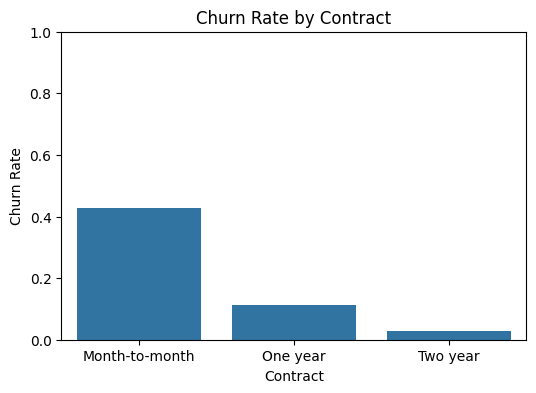

In [ ]:
#2-1 Contract(계약유형)에 따른 이탈 시각화
plt.figure(figsize=(6,4))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title('Churn Rate by Contract')
plt.xlabel('Contract')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

In [ ]:
#2-2.PaymentMethod(결제방식)별 이탈률
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .mean()
      .sort_values(ascending=False)
)

payment_churn



,Churn
PaymentMethod,
Electronic check,0.452854
Mailed check,0.191067
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431


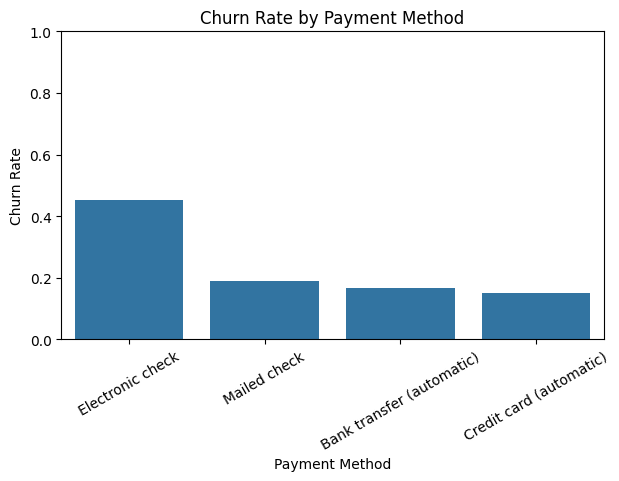

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

In [ ]:
#InternetService(인터넷서비스)별 이탈률
internet_churn = (
    df.groupby('InternetService')['Churn']
      .mean()
      .sort_values(ascending=False)
)
internet_churn

,Churn
InternetService,
Fiber optic,0.418928
DSL,0.189591
No,0.074050


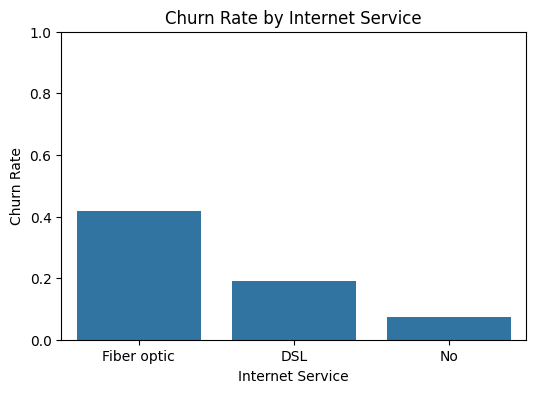

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

In [ ]:
#TechSupport(기술지원서비스) 여부별 이탈률
tech_churn = (
    df.groupby('TechSupport')['Churn']
      .mean()
      .sort_values(ascending=False)
)
tech_churn

,Churn
TechSupport,
No,0.416355
Yes,0.151663
No internet service,0.074050


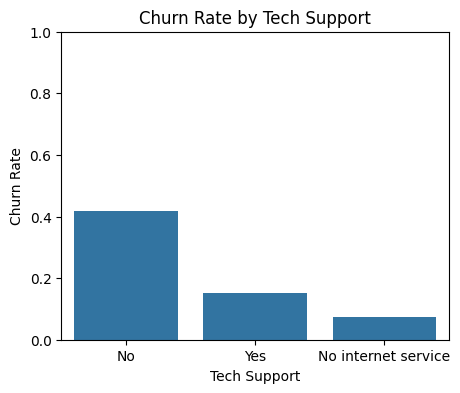

In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(
    x=tech_churn.index,
    y=tech_churn.values
)
plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

### 2-1. 범주형 변수별 이탈률 분석 요약

EDA 결과, 고객 이탈은 특정 범주형 특성에서 뚜렷하게 집중되는 경향있음

- **Contract(계약구조)**
  - **Month-to-month 계약 고객의 이탈률이 약 42%로 가장 높음**
  - 계약 기간이 길어질수록 (1년, 2년) 이탈률은 급감

- **PaymentMethod(결제방식)**
  - **Electronic check 이용 고객의 이탈률이 다른 결제 방식 대비 현저히 높음**
  - 메일체크, 자동이체 및 카드 결제 고객은 상대적으로 낮은 수치 (0.2 이하)로 비슷한 수준에서 유지되는 것을 확인

- **InternetService(인터넷서비스유형)**
  - **Fiber optic 서비스를 이용하는 고객의 이탈률이 가장 높음**
  - DSL 및 인터넷 미이용 고객은 낮은 이탈률

- **TechSupport(기술지원서비스)**
  - **기술 지원 서비스를 이용하지 않는 고객의 이탈률이 높음**
  - TechSupport 이용 고객은 이탈률이 상대적으로 낮았고, 인터넷 미이용 고객은 현저히 낮음

→ 범주형 변수 분석 결과, **계약 구조, 결제 방식, 서비스 유형, 기술지원 여부가
고객 이탈에 중요한 영향을 미치는 요인**으로 확인

---

#### 2-2. 수치형 변수 분포 비교
- 이탈 고객과 유지 고객 간에  
  **가입 기간 및 요금 수준이 어떻게 다른지**를 비교한다.
- 수치형 변수의 분포를 시각화하여  
  이탈 고객의 행동적 특징을 파악한다.

**분석 대상 변수**
- `tenure`
- `MonthlyCharges`
- (필요 시) `TotalCharges`



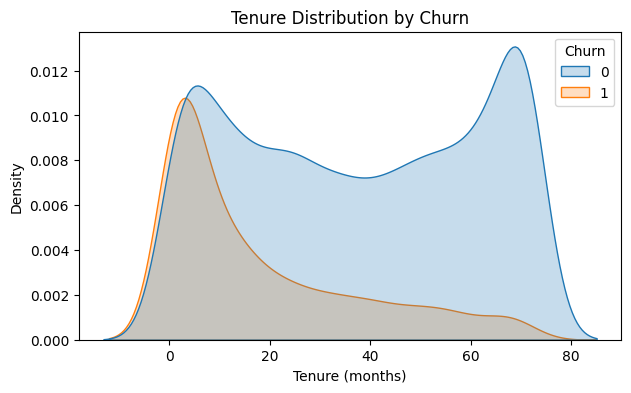

In [ ]:
#tenure(가입 기간)) 분포를 이탈 유무에 따른 확률 밀도곡선(KDE)으로 확인

#가입 초반 시기에 이탈이 주로 발생한다.

plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

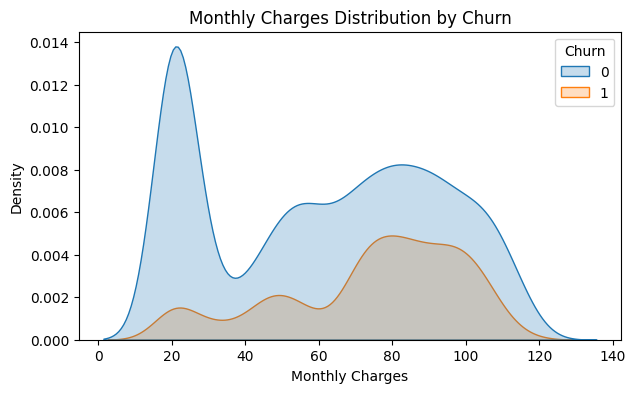

In [ ]:
#MonthlyCharges 분포를 이탈 유무에 따른 확률밀도곡선으로 확인
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.show()

#이탈 고객분포가 중-고요금 구간 (70-100)에 상대적으로 많음. 상대적으로 저요금 구간에서는 유지고객이 압도적임

In [ ]:
#이탈 유무에 따른 두 수치형 변수의 평균값 차이 비교
df.groupby('Churn')[['tenure', 'MonthlyCharges']].describe().round(2)

tenure                                            MonthlyCharges  \
        count   mean    std  min   25%   50%   75%   max          count   
Churn                                                                     
0      5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0         5174.0   
1      1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0         1869.0   

                                                        
        mean    std    min    25%    50%   75%     max  
Churn                                                   
0      61.27  31.09  18.25  25.10  64.43  88.4  118.75  
1      74.44  24.67  18.85  56.15  79.65  94.2  118.35

### 2-1. 수치형 변수별 이탈률 분석 요약수치형 변수 분석 결과,
**이탈 고객은 가입 초기(tenure가 짧은 구간)에 집중**되는 경향을 보였으며,  
상대적으로 **월 요금이 높은 구간(70-100)에 더 많이 분포**  
이는 초기 고객 경험과 요금 부담이 이탈에 영향을 미칠 가능성을 시사함

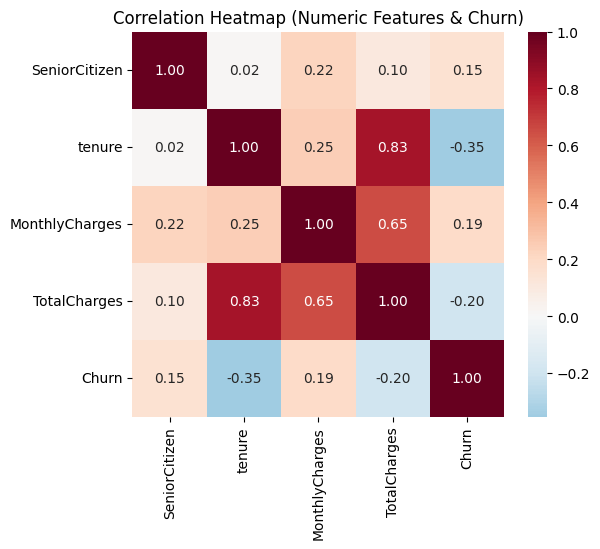

In [ ]:
# 2-2. 수치형 + 타겟 변수 상관계수 히트맵

import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 변수 + 타겟만 선택
corr_df = df[[
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]]

# 상관계수 계산
corr = corr_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)
plt.title("Correlation Heatmap (Numeric Features & Churn)")
plt.show()

###2-2. 수치형+이진타겟 변수들의 상관도 확인 결과
상관계수 히트맵은 변수 간 전반적인 방향성을 빠르게 파악하기 위해 활용함.
- 가입기간과 누적요금은 매우 높은 상관이며, 중복 정보(당연한 관계)임을 확인 (다중공선성(Multicollinearity) 문제 인지)
- 가입기간과 이탈은 음의 상관 (가입기간이 짧을 수록 이탈이 높았다의 EDA와 일관성있는 결과)
- 월요금, 고령자 여부는 이탈과 양의 상관 방향을 갖는다는 점을 직관적으로 확인


---
## **3. 초기 가설 설정**
### [가설 1] (범주형 변수 기반)
월계약 유형**의 고객이 다른 장기계약형 (1년, 2년)에 비해 현저하게 이탈이 높음.  

-> **단기 계약(Month-to-month)을 이용하는 고객은  
장기 계약 고객에 비해 이탈할 가능성이 높다.**

### [가설 2] (수치형 변수 기반)
고객 이탈은 가입 기간(tenure) 초반부에 주로 발생함.   
-> **가입기간이 짧을수록 고객 이탈 가능성이 높을 것이다.**

### (보조 가설 후보)
- **Electronic check 결제 방식을 사용하는 고객은 이탈 가능성이 높다.**
- **월 요금(MonthlyCharges)이 높은 고객은 이탈 가능성이 증가한다.**

---
## **4.통계적 가설 검정 (설명력 위주)**

가설1과 2는 서로 연관성 있는 변수로 보임.   
그래서 각 분리 검정보다 동시에 포함한 모델을 통해 독립적인 영향력을 먼저 검정하기 위해   
로지스틱 회귀를 사용함.
로지스틱 회귀는 교란 변수를 통제한 상태에서   
각 변수 영향방향과 크기를 오즈비로 해석할 수 있어서 적절한 방법이라고 판단함.    


🎯 **이진 타겟이고 결과의 확률해석이 중요한 문제라도 판단해 로지스틱 회귀+오즈비 해석 선택**

예) 계수 해석 목표
- two year 대비 one year / Month - to- month 유의하게 이탈한다고 말할 수 있는가?
- tenure 가입기간이 1개월 증가할 때의 이탈률은 얼마나 변화하는가?


---
**[STEP1] Contract 더미 컬럼 생성 (기준 Two year)**

In [ ]:
# Contract 변수를 범주형(Category)으로 변환하고
# 범주 순서를 지정하여 기준(reference)을 'Two year'로 설정→ 이후 더미 인코딩 시 Two year가 기준
df['Contract'] = pd.Categorical(
    df['Contract'],
    categories=['Two year', 'One year', 'Month-to-month'],
    ordered=True
)

# Contract(범주형) + tenure(연속형)를 모델 입력 변수(X)로 선택
# drop_first=True를 사용하여 기준 범주(Two year)를 제거
# → 회귀 계수 해석을 명확하게 하기 위함
X = pd.get_dummies(
    df[['Contract', 'tenure']],
    drop_first=True
)

# statsmodels는 bool 타입을 허용하지 않으므로
# 더미 컬럼(True/False)을 0/1 정수형으로 변환
X = X.astype(int)

# 타겟 변수(y): 고객 이탈 여부 (0 = 유지, 1 = 이탈)
y = df['Churn']

# 입력 데이터 구조 확인
X.head()

,tenure,Contract_One year,Contract_Month-to-month
0,1,0,1
1,34,1,0
2,2,0,1
3,45,1,0
4,2,0,1


---
**[STEP2] statsmodels용 데이터 준비와 로지스틱회귀 모델로 통계적 가설 검정**

In [ ]:
import statsmodels.api as sm

# statsmodels는 절편(intercept)을 자동으로 추가하지 않기 때문에
# 상수항(constant)을 명시적으로 추가
X_sm = sm.add_constant(X)

# statsmodels용 타겟 변수 설정
y_sm = y

# Logit 모델 정의
# → 이진 분류 문제에서 각 변수의 통계적 유의성을 검정하기 위함
logit_model = sm.Logit(y_sm, X_sm)

# 모델 학습 (최대우도추정, MLE)
result = logit_model.fit()


# 회귀계수, p-value, 신뢰구간이 포함된
# 통계적 해석용 결과 요약표 출력
result.summary()

Optimization terminated successfully.
         Current function value: 0.473175
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7039
Method:                           MLE   Df Model:                            3
Date:                Fri, 26 Dec 2025   Pseudo R-squ.:                  0.1822
Time:                        15:43:57   Log-Likelihood:                -3332.6
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.6371      0.170    -15.479      0.000      -2.971      -2.303
tenure                     -0.0167      0.002     -9.750      0.000      -0.020      -0.013
Contract_One year           1.2362      0.170      7.272      0.000       0.903       1.569
Contract_Month-to-month     2.6363      0.161     16.376      0.000       2.321       2.952
===========================================================================================
"""

### 4-1. 로지스틱회귀모델 통계적 가설검정 결과

LLR-p-value 값이 .000이므로 **본 로지스틱 회귀 모델은 상수항만 포함한 모형 대비  
통계적으로 유의미한 설명력을 가지는 것으로 확인**  

- **가설2 검정. Tenure(가입기간)**
  - coef 가 -0.0167이고 유의하므로, 가입기간이 길어질수록 이탈 위험(오즈)은 감소한다. (반대방향)
  - 95% 신뢰구간도 모두 음수여서 효과 방향이 안정적


- **가설1 검정. Contract(계약유형)**
  - 아래문단 세번째줄 보면 coef 가 1.2362이고 유의하므로, 2년 장기계약 고객들과 비교하여 1년 계약 고객들은 이탈 위험(오즈)이 증가한다. (같은 방향)
  - 아래문단 네번째 줄 보면 coef가 2.6363이고 유의하므로, 2년 장기계약 고객들과 비교하여 월단위 단기계약 고객들은 이탈 위험(오즈)이 크게 증가한다. (같은방향)



In [ ]:
import numpy as np
import pandas as pd

# 회귀계수
params = result.params

# 신뢰구간
conf = result.conf_int()
conf.columns = ['CI_lower', 'CI_upper']

# 오즈비 테이블 생성
odds_ratio = pd.DataFrame({
    'Odds_Ratio': np.exp(params),
    'CI_lower': np.exp(conf['CI_lower']),
    'CI_upper': np.exp(conf['CI_upper']),
    'p_value': result.pvalues
})

odds_ratio

,Odds_Ratio,CI_lower,CI_upper,p_value
const,0.071566,0.051250,0.099935,4.771813e-54
tenure,0.983444,0.980150,0.986750,1.843663e-22
Contract_One year,3.442534,2.467075,4.803682,3.536076e-13
Contract_Month-to-month,13.961029,10.183372,19.140057,2.816900e-60


### 4-3. 오즈비(Odds Ratio) 결과
오즈(Odds)는  **이탈할 가능성 : 이탈하지 않을 가능성의 비율**을 의미하며,  
오즈비(Odds Ratio, OR)는 **기준 조건 대비 이탈 위험이 얼마나 증가하거나 감소했는지**를 나타냄

- OR = 1 : 기준 대비 영향 없음  
- OR > 1 : 이탈 위험 증가  
- OR < 1 : 이탈 위험 감소  

로지스틱 회귀 분석 결과는 회귀계수(coef)를 지수화(exp)하여 오즈비(Odds Ratio)로 변환한 뒤 재해석


### 🔹 통계적 검정 결과 요약 (Odds Ratio 기준)

- **가입 기간(tenure)**  
  가입 기간의 오즈비는 **0.983**으로,  
  가입 기간이 1개월 증가할 때마다 고객 이탈 오즈는 약 **1.7% (1 − 0.983)** 감소하는 패턴 확인  
  이는 고객 이탈이 가입 초기 단계에서 집중적으로 발생하는 경향이 있음을 시사

- **계약 유형(Contract)**  
  Two year 계약을 기준(reference)으로 비교한 결과,
  - One year 계약 고객의 이탈 오즈는 약 **3.4배** 높았으며,
  - **Month-to-month 계약 고객의 이탈 오즈는 약 14배(13.96)** 높은 것으로 확인

  이는 계약 기간이 짧을수록 고객 이탈 위험이 단계적으로 크게 증가함을 의미한다.

---

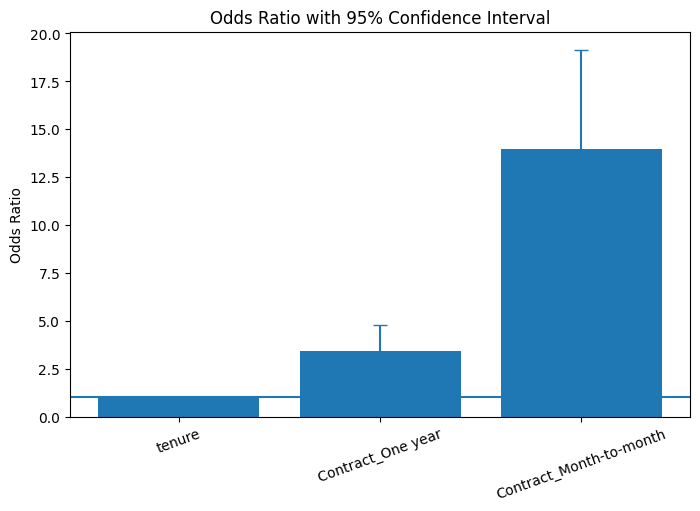

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 절편(constant)은 해석 대상이 아니므로 제외
plot_df = odds_ratio.drop(index='const')

# 변수명
x = plot_df.index

# OR 값
or_values = plot_df['Odds_Ratio']

# 신뢰구간 (에러바 길이 계산)
yerr = [
    or_values - plot_df['CI_lower'],
    plot_df['CI_upper'] - or_values
]

plt.figure(figsize=(8, 5))

# OR 막대
plt.bar(x, or_values)

# 신뢰구간 에러바
plt.errorbar(
    x,
    or_values,
    yerr=yerr,
    fmt='none',
    capsize=5
)

# 기준선 (OR = 1)
plt.axhline(1)

plt.ylabel('Odds Ratio')
plt.title('Odds Ratio with 95% Confidence Interval')
plt.xticks(rotation=20)
plt.show()

### 🔹 오즈비 및 신뢰구간 시각화 해석

오즈비와 95% 신뢰구간을 함께 시각화한 결과,

- **Month-to-month 계약 변수는 가장 높은 오즈비를 보이며,
  고객 이탈에 가장 큰 영향을 미치는 요인으로 확인됨.**
- **가입 기간(tenure)은 오즈비가 1보다 작고,
  신뢰구간 역시 기준선(OR = 1)을 하회하여
  이탈 위험을 유의미하게 감소시키는 요인으로 나타남.

---

### 4. 통계적 가설 검정 결론
본 로지스틱 회귀 기반 통계 분석을 통해,
- 단기 계약 고객일수록 이탈 위험이 높다는 가설과
- 고객 이탈이 가입 초기 단계에서 집중적으로 발생한다는 가설이
모두 통계적으로 지지되었음.

##4.4 피쳐엔지니어링 (통계 검정 결과를 새 변수로 바꿈) -모델링용
통계적 가설 검정을 통해 확인된 핵심 요인들을  
예측 모델이 보다 효과적으로 학습할 수 있도록  
파생 변수(Feature Engineering)로 재구성함  

[조건을 충족한 그룹과 그렇지 않은 그룹간의 비교를 좀 더 뚜렷하게 학습할 수 있도록 플래그 생성 변수]
- 가입 초기 고객 여부,
- 월 단위 계약 여부,  
- 요금 대비 체감 부담


In [ ]:
# df_clean: 통계 검정 및 해석용
# df_model: 예측 모델링용

df_clean = df.copy()

df_model = df_clean.copy()

#가입초기 플래그 생성
df_model['early_tenure'] = (df_model['tenure'] <= 3).astype(int)
#월 계약 플래그 생성
df_model['is_monthly_contract'] = (df_model['Contract'] == 'Month-to-month').astype(int)
#고객이 느끼는 요금부담의 강도를 월요금을 가입기간으로 나눠서 표현
df_model['charge_per_tenure'] = df_model['MonthlyCharges'] / (df_model['tenure'] + 1)

---
##5.예측 모델링
###5-1. 사전 고려사항 : 정확도 외 다른 평가지표를 왜 고민해봐야 하는지?
이탈 데이터의의 특성 : **타겟 불균형**

	•	전체 고객 중 이탈 고객 비율 ≈ 26%
	•	즉, 클래스 불균형 문제 존재

만약 모델이:
	•	모든 고객을 “유지(No)”라고 예측해도
→ Accuracy ≈ 73% 밖에 안되고, 이탈 고객을 잡지 못하므로 비즈니스측면에선 그러한 접근법이 큰 의미가 없음.

그래서 중요한 지표는  
1️⃣ Precision (정밀도)  
이탈이라고 예측한 고객 중, 실제 이탈한 비율

	•	마케팅 비용 낭비와 직결

2️⃣ Recall (재현율)
실제 이탈 고객 중, 모델이 맞춘 비율

	•	이탈 고객을 얼마나 놓치지 않는가

3️⃣ F1-Score  
Precision과 Recall의 조화 평균

	•	이탈 예측처럼 놓치면 손해인 문제에 적합한 평가지표

4️⃣ ROC-AUC  

	•	임계값 관계없이 이탈 고객과 유지 고객을 얼마나 잘 구분하는지에 대한 분류 성능 평가 지표

###**[예측 모델링 평가지표 분석 방향]**  
**본 프로젝트에서는 이탈 고객을 놓치는 비용이 크기 때문에,
Recall과 Precision을 동시에 고려하는 F1-Score를
가장 중요한 평가지표로 선정한다.  
또한 모델의 전반적인 분류 성능을 확인하기 위해 보조 지표로 ROC-AUC를 함께 활용한다.**

그리고 성능평가 전 불균형 보정을 위한 class_weight과 threshold 고려

---
##5. 예측 모델링 (df_model : FE 끝낸 전체 변수 기반)

In [ ]:
import pandas as pd
import numpy as np

#X, y 만들고, 학습 및 테스트 셋 분리

from sklearn.model_selection import train_test_split

# ✅ 타겟 변수 (0=유지, 1=이탈)
y = df_model['Churn']  # 통계/모델링에서 사용할 타겟

# ✅ 입력 변수: ID와 타겟 제외한 모든 컬럼(파생변수 포함)
X = df_model.drop(columns=['customerID', 'Churn'])

# ✅ 범주형 변수 원핫 인코딩 (계약/결제/서비스 가입 여부 등)
X = pd.get_dummies(X, drop_first=True)

# ✅ Train/Test split (불균형 데이터이므로 stratify 필수)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 테스트 20%
    random_state=42,    # 재현성 확보
    stratify=y          # 이탈 비율 유지
)

# ✅ sanity check (shape/이탈 비율)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Churn rate train:", y_train.mean().round(4), "test:", y_test.mean().round(4))

X_train: (5634, 33) X_test: (1409, 33)
Churn rate train: 0.2654 test: 0.2654


In [ ]:
#3개 모델 학습 및 성능 비교표 (Class_weight 동일 적용)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score
)

# ✅ 모델 3종 (공정 비교 위해 class_weight 동일 적용)
models = {
    "Logistic Regression (Baseline)": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"     # 불균형 보정
    ),
    "Decision Tree (Interpretable)": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"     # 불균형 보정
    ),
    "Random Forest (High-Performance)": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",    # 불균형 보정
        n_jobs=-1
    )
}

rows = []

for name, model in models.items():
    model.fit(X_train, y_train)                    # 학습
    y_pred = model.predict(X_test)                 # 클래스 예측
    y_proba = model.predict_proba(X_test)[:, 1]    # 이탈 확률 예측

    rows.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

result_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
result_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (Baseline),0.508621,0.788770,0.618449,0.847570
2,Random Forest (High-Performance),0.633562,0.494652,0.555556,0.826375
1,Decision Tree (Interpretable),0.536517,0.510695,0.523288,0.675884


###5. 세 모델 간 성능 비교 결과
	이탈 예측 문제의 본질은
	•	이탈 고객을 놓치지 않는 것 (Recall)
	•	동시에 불필요한 오탐을 최소화하는 것 (Precision)
    이것을 균형있게 달성하는데 있음.

세 가지 모델(Logistic Regression, Decision Tree, Random Forest)의 성능을    
 F1-Score(Precision과 Recall의 조화평균), ROC-AUC (모델의 전반적인 분리 능력) 기준으로 비교한 결과
**Logistic Regression 모델을 최종 예측 모델로 선정**

---
##5. Logistic Regression 예측모델의 최종 성능 분석
###5-1. 해당 최종 예측모델로 재학습 후, Confusion Matrix 분류 지표 해석
🎯 목적
	•	이탈 고객을 얼마나 잘 잡아내는지
	•	어떤 유형의 오류를 더 많이 내는지 확인

In [ ]:
# ✅ 최종 모델 정의 (선택한 모델로 고정)
final_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

# ✅ 최종 모델 학습
final_model.fit(X_train, y_train)

# ✅ 예측/확률
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


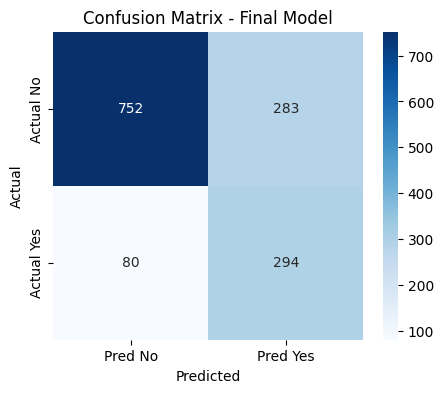

Classification Report (Final Model)
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ✅ 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred)

# ✅ 혼동행렬 시각화
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred No', 'Pred Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ✅ 분류 리포트(Precision/Recall/F1/support)
print("Classification Report (Final Model)")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))


###5-1. 혼동행렬 (Confusion Matrix)결과 해석

	실제 유지 고객(Non-Churn) 1,035명 중
	•	752명은 유지로 정확히 예측
	•	283명은 이탈로 잘못 예측됨 (오탐)
	실제 이탈 고객(Churn) 374명 중
	•	294명을 이탈로 정확히 탐지
	•	80명을 유지로 놓침

👉 본 모델은 이탈 고객의 79%를 사전에 탐지(Recall = 0.79) 하여,
이탈 가능 고객을 선별하는 선제적 방어 모델로서 효과적인 성능을 보임

기본 임계값 0.5 기준에서 이탈 고객의 79%를 탐지했으나, 실제 운영 환경에서는 마케팅 비용과 이탈 손실간의 트레이드 오프에 따라 임계값을 조정해 모델을 유연하게 활용 가능함.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
)

# 1) 최종 모델이 예측한 "이탈(1) 확률" 가져오기
#    - predict_proba[:, 1] : 클래스 1(이탈)일 확률만 뽑음
y_proba = final_model.predict_proba(X_test)[:, 1]

# 2) 임계값 후보 리스트 만들기 (0.30 ~ 0.50, 0.05 간격)
thresholds = np.arange(0.30, 0.51, 0.05)

rows = []

for t in thresholds:
    # 3) 임계값 기준으로 확률 -> 클래스(0/1) 변환
    #    - 확률이 t 이상이면 이탈(1)로 예측
    y_pred_t = (y_proba >= t).astype(int)

    # 4) 지표 계산
    prec = precision_score(y_test, y_pred_t, zero_division=0)  # 이탈로 찍은 것 중 진짜 이탈 비율
    rec  = recall_score(y_test, y_pred_t, zero_division=0)     # 실제 이탈 중 잡아낸 비율
    f1   = f1_score(y_test, y_pred_t, zero_division=0)         # Precision/Recall 균형
    acc  = accuracy_score(y_test, y_pred_t)                    # 전체 정확도

    # 5) 혼동행렬에서 TP/FP/FN/TN도 같이 뽑아두기 (발표/해석용)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    rows.append({
        "threshold": round(float(t), 2),
        "precision(churn=1)": prec,
        "recall(churn=1)": rec,
        "f1(churn=1)": f1,
        "accuracy": acc,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })

# 6) 표로 정리 (F1 기준으로 정렬해서 보기 좋게)
threshold_df = pd.DataFrame(rows).sort_values("f1(churn=1)", ascending=False)

threshold_df

,threshold,precision(churn=1),recall(churn=1),f1(churn=1),accuracy,TP,FP,FN,TN
4,0.50,0.509532,0.786096,0.618297,0.742370,294,283,80,752
3,0.45,0.484848,0.812834,0.607393,0.721079,304,323,70,712
2,0.40,0.467532,0.866310,0.607310,0.702626,324,369,50,666
1,0.35,0.449062,0.895722,0.598214,0.680625,335,411,39,624
0,0.30,0.433417,0.922460,0.589744,0.659333,345,451,29,584


###5-2. 임계값 조정으로 모델 평가지표 한 번 더 점검한 결과
“Threshold를 낮추면 이탈 고객을 최대한 많이 포착하는 전략이고,
Threshold 0.5는 마케팅 비용과 탐지 성능 간의 운영상 균형점에 해당함.
본 프로젝트에서는 **실무 적용 가능성을 고려해 0.5를 최종 기준으로 선택**”

###5-3. 핵심 요인 분석 (중요도)

In [ ]:
import numpy as np
import pandas as pd

# 모델이 실제 학습한 feature 이름
features = X_train.columns

# 회귀 계수
coef = final_model.coef_[0]

# 오즈비 (Odds Ratio)
odds_ratio = np.exp(coef)

# 🔹 오즈 변화율 (%)
# OR > 1  → (OR - 1) * 100 % 만큼 이탈 오즈 증가
# OR < 1  → (1 - OR) * 100 % 만큼 이탈 오즈 감소
odds_change_pct = (odds_ratio - 1) * 100

# 중요도 테이블 생성
importance_df = pd.DataFrame({
    "feature": features,
    "coef": coef,
    "odds_ratio": odds_ratio,
    "odds_change_%": odds_change_pct,
    "abs_coef": np.abs(coef)
})

# 🔥 중요도(|coef|) 기준 내림차순 정렬
importance_df = importance_df.sort_values(
    by="abs_coef",
    ascending=False
).reset_index(drop=True)

# 상위 5개 변수
top5_features = importance_df.head(10)

# 보기 좋게 반올림
top5_features[["coef", "odds_ratio", "odds_change_%"]] = (
    top5_features[["coef", "odds_ratio", "odds_change_%"]].round(4)
)

top5_features

/tmp/ipython-input-1380615516.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5_features[["coef", "odds_ratio", "odds_change_%"]] = (


,feature,coef,odds_ratio,odds_change_%,abs_coef
0,InternetService_Fiber optic,1.5242,4.5916,359.1565,1.524221
1,Contract_One year,0.8750,2.3989,139.8853,0.874991
2,Contract_Month-to-month,0.8190,2.2682,126.8151,0.818965
3,is_monthly_contract,0.8190,2.2682,126.8151,0.818965
4,StreamingMovies_Yes,0.5884,1.8012,80.1177,0.588440
5,StreamingTV_Yes,0.5571,1.7456,74.5559,0.557075
6,MultipleLines_Yes,0.4620,1.5872,58.7211,0.461979
7,early_tenure,0.3869,1.4724,47.2365,0.386870
8,PaymentMethod_Electronic check,0.3665,1.4426,44.2624,0.366464
9,PaperlessBilling_Yes,0.3401,1.4051,40.5079,0.340093


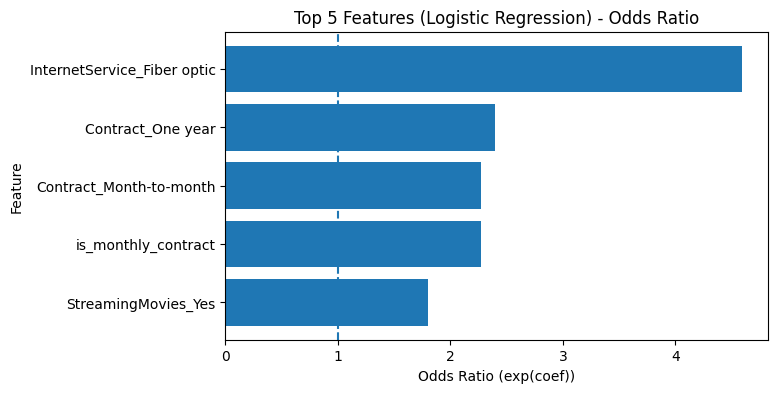

In [ ]:
import matplotlib.pyplot as plt

top5_plot = top5_features.sort_values("odds_ratio", ascending=True).copy()

plt.figure(figsize=(7,4))
plt.barh(top5_plot["feature"], top5_plot["odds_ratio"])
plt.axvline(1, linestyle="--")  # OR=1 기준선
plt.title("Top 5 Features (Logistic Regression) - Odds Ratio")
plt.xlabel("Odds Ratio (exp(coef))")
plt.ylabel("Feature")
plt.show()

###5-3. 상위 5개 중요 변수 해석 요약 (Logistic Regression) - 모델 내부 가중치
예측을 위한 머신러닝 모델 학습 결과, 이탈(Churn=1)에 영향을 미치는 상위 5개 핵심 변수는 다음과 같음

**1. 광랜 인터넷 사용 (InternetService_Fiber optic)**
- DSL이나 인터넷 미사용 고객 대비, 광랜(Fiber optic) 사용자의 이탈 오즈가 약 4.59배 높음 (위험도 359.16% 증가)
- 인사이트: 서비스 품질 불만족이나 경쟁사의 공격적인 마케팅이 광랜 고객군에 집중되어 있을 가능성이 매우 높음 (가장 강력한 이탈 신호).

**2. 1년 계약 (Contract_One year)**
- 2년 계약 고객 대비, 1년 계약 고객의 이탈 오즈는 약 2.40배 높음 (위험도 139.89% 증가)
- 인사이트: 2년 이상의 장기 계약이 아닌 경우, 계약 만료 시점을 전후로 이탈 위험이 크게 상승함을 의미함.

**3. 월 단위 계약 (Contract_Month-to-month / is_monthly_contract)**
- 2년 계약 고객 대비 월 단위 계약 고객의 이탈 오즈는 약 2.27배 높음 (위험도 126.82% 증가).인사이트: 언제든 해지가 가능한 계약 구조 자체가 이탈의 상시적 트리거로 작용하고 있습니다.

**4. 영화 스트리밍 이용 (StreamingMovies_Yes)**
- 영화 스트리밍 서비스를 이용하는 고객은 그렇지 않은 고객보다 이탈 오즈가 약 1.80배 높음 (위험도 80.12% 증가)
- 인사이트: 고사양 부가 서비스를 이용하는 헤비 유저층일수록 요금 부담이나 서비스 품질에 민감하여 이탈할 확률이 높음

**5. 가입 기간 (tenure)**
- 가입 기간이 1개월 증가할 때마다 이탈 오즈는 약 0.98배로 감소하며, 이는 위험도가 매달 약 2.29%씩 낮아짐을 의미
- 인사이트: 시간이 지날수록 고객이 서비스에 고착(Lock-in)되는 안정화 효과가 통계적으로 입증   
**(예측 모델 내부 가중치에서는 순위가 7위로 떨어진거 같은데 여전히 중요한 변수임)**



### **🔍 모델 간 중요도 역전 현상에 대한 인사이트**

단순 통계 모델에서 '계약 구조'가 1위였으나, 최종 예측 모델에서 **'광랜 서비스(Fiber optic)'가 압도적 1위(오즈비 4.59)**로 바뀜.

1. **단순 현상을 넘어선 본질 파악**:
   - 월 단위 계약은 이탈의 '통로'일 뿐이며, 여러 변수를 함께 고려하였을 때, 주요 이탈의 동기는 **광랜 서비스 품질**일 가능성이 매우 높습니다.
   
2. **타겟 마케팅의 정교화**:
   - 단순히 "계약 기간이 짧은 사람"을 잡는 것보다, **"광랜을 쓰면서 계약 기간이 짧은 고객"**에게 방어 혜택을 집중한다면 비용 대비 효율이 훨씬 높아질 것임

3. **서비스 품질 점검의 필요성**:
   - 광랜 이용자의 이탈 오즈가 4.6배 높다는 것은 기술적 오류, 설치 지연, 혹은 경쟁사의 광랜 교체 프로모션에 취약하다는 강력한 신호이므로 단순 마케팅 차원에서의 접근보다는 **네트워크 품질 부서와의 협업**이 필요함을 시사함.


---
## **6.전략 제언 (Actionable Strategy)**

✅ **전략 1. 광랜(Fiber) 가입 초기 고객 집중 관리 전략**

대상 고객

	•	광랜(Fiber optic) 서비스 이용 고객 중
	•	가입 1–3개월 이내 신규 고객
	•	Month-to-month 또는 1년 계약을 보유한 고객

실행 방안

	•	가입 첫 달에 광랜 고객 전용 온보딩 프로그램 운영(설치 완료 후 품질 체크, 서비스 이용 가이드, 요금·혜택 구조 명확화)
	•	가입 후 1개월·2개월 시점에 품질 및 만족도 점검(속도·안정성·체감 품질 중심 설문 및 이상 감지 시 선제적 조치)
	•	초기 불만 발생 고객에 대해 즉시 맞춤 케어 및 기술 지원 연계

기대 효과

	•	이탈이 집중되는 초기 구간에서의 선제적 개입
	•	광랜 서비스 품질 불만의 조기 해소를 통한 이탈률 감소
	•	초기 안정화 성공 시 장기 고객 전환 및 Lock-in 효과 강화



✅ **전략 2. 광랜 단기 계약 고객의 선택적 장기 계약 전환 유도**

대상 고객

	•	광랜(Fiber optic) 이용 고객 중
	•	Month-to-month 또는 1년 계약 고객

실행 방안

	•	광랜 고객 대상 선택적 장기 계약 전환 인센티브 제공
	•	2년 계약 전환 시 요금 할인 + 품질 보증 옵션(AS 우선 지원 등) 결합
	•	계약 갱신 시점에 ‘광랜 장기 이용 고객 혜택’ 중심 캠페인 운영
	•	장기 이용 고객의 안정성·만족도·혜택 사례 중심 커뮤니케이션
	•	단순 할인보다는 “안정적 품질 + 장기 혜택” 메시지 강조

기대 효과

	•	계약 구조를 통한 이탈 가속 요인 완화
	•	광랜 고객의 이탈을 억제하는 선택적 고객 락인 효과
	•	비용 대비 효율적인 타겟 기반 유지 전략 구현


✅ **전략 3. 부가 서비스(스트리밍) 이용 고객 이탈 완화 전략**

대상 고객

	•	영화 스트리밍(StreamingMovies) 등 부가 서비스 이용 고객
	•	특히 광랜(Fiber optic) 서비스와 부가 서비스를 함께 이용하는 고객
	•	중·고요금 구간의 헤비 유저 고객군

실행 방안

	•	스트리밍 이용 고객 대상 체감 품질 중심 관리 서비스 적용 (네트워크 품질 부서와의 협업을 통해 속도, 버퍼팅, 안정성 개선)
	•	부가 서비스 이용 고객에게 요금 대비 제공 가치를 명확화하고 서비스 장애 발생 시 보상 정책 및 개선 계획을 명확히 안내


기대 효과

	•	고사양 부가 서비스 이용 고객의 기대 - 경험 불일치 해소
	•	헤비 유저 고객군의 체감 불만 감소를 통한 이탈 리스크 완화

---
🧩 ###**KPT 회고 (Keep · Problem · Try)**

✅ Keep (잘한 점)

	•	EDA → 가설 설정 → 통계 검정 → 예측 모델링 → 전략 제언까지 분석 전 과정을 논리적으로 진행
	•	오즈비, 신뢰구간, 임계값 등 통계적 관점에서 데이터를 해석하기 위한 노력을 꾸준히 함.
	•	상관관계 히트맵에서 다중공선성에 대한 사전 인지를 통해 중복성 해결을 위한 새로운 변수 생성에 대한 접근을 시도함.


⚠️ Problem (아쉬운 점)

	•	통계 검정용 모델과 예측 모델의 **목적 차이(설명 vs 예측)**를 초반에 명확히 구분하여 데이타프레임을 구분했어야하는데 뒤늦게 알아챔.
	•	처음에 원본 데이타와 가설에서 꼽은 변수의 통계검정 결과에만 의존해서 모델성능 비교를 했더니 기대보다 예측률이 좋지 않아서 전처리 및 피처 엔지니어링을 다시 신경써서 진행했더니 최적 모델이 다른 것으로 변경됨. 그 이후 다시 모델링하고 결과 정리하느라고 너무 분석 시간이 오래 걸려 중도에 포기하고 싶었음.
    •   클래스 불균형 대응을 모델링 후반부에서야 깨닫고 다시 수정하느라 오래걸림
	•   결과물 정리한 이후 로지스틱 회귀모델 돌리기 전 연속 변수에 대한 스케일링 적용을 안했다는 것을 뒤늦게 깨달음 (이건 그냥 나중에 수정할 계획임.오늘 이정도만 진행하는데도 너무 힘들었음)

🔄 Try (다음에 시도할 점)

	•	분석 초반에 ① 통계 검정용 데이터프레임 / ② 예측 모델링용 데이터프레임을 명확히 분리하여 목적별 흐름을 더 선명하게 가져가기.
	•	모델 성능 비교 시 임계값·클래스 불균형 전략을 명시적으로 포함한 실험 설계를 먼저 구성하기.
	•	“이 변수는 왜 중요한가?”를 EDA → 모델 결과 → 전략 제언으로 연결하는 한 문장 설명을 각 주요 변수마다 미리 정리해두기.

---